In [1]:
import os
os.chdir('/workspace/d335598e-dde4-4aad-a9c4-f313d0cde4a0')
print(os.getcwd())
print(os.listdir('.'))


/workspace/d335598e-dde4-4aad-a9c4-f313d0cde4a0
['generate_ldh_zeros_run.py', '.kernel_llm_logs_1.txt', '.prompts', 'ldh_ckpt_03578_meta.json', '.config', 'memory', 'ldh_ckpt_03578.npy']


In [2]:
with open('generate_ldh_zeros_run.py') as f:
 print(f.read())


#!/usr/bin/env python
"""
Generate the first 5000 critical-line zeros of the Davenport-Heilbronn L-function.
Adapted: configurable WORK_DIR via env; time-budget guard for graceful partial save.
"""
import os, sys, time, json, re
import numpy as np
import mpmath
import cypari2

WORK_DIR = os.environ.get('LDH_WORK_DIR', os.path.dirname(os.path.abspath(__file__)))
os.chdir(WORK_DIR)
CKPT_DIR = os.path.join(WORK_DIR, 'checkpoints_ldh')
os.makedirs(CKPT_DIR, exist_ok=True)
LOG_PATH = os.path.join(WORK_DIR, 'run_log.txt')

TIME_BUDGET = float(os.environ.get('LDH_TIME_BUDGET', '10800')) # seconds; default 3h

def log(msg):
 line = f"[{time.strftime('%H:%M:%S')}] {msg}"
 print(line, flush=True)
 with open(LOG_PATH, 'a') as f:
 f.write(line + '\n')

log(f"Starting L_DH zero generation; WORK_DIR={WORK_DIR}; TIME_BUDGET={TIME_BUDGET:.0f}s")

mpmath.mp.dps = 50
pari = cypari2.Pari()
pari.allocatemem(1024*1024*1024)

T_MAX = 5200
DPS_PARI = 80

pari(f"default(realprecision, {DPS_PARI})")
pari("gz5 

In [3]:
with open('generate_ldh_zeros_run.py') as f:
 content = f.read()
print(content[2000:5500])


 mpmath.mpf(fix_pari_str(pari("imag(v1)"))))
 Lcb = mpmath.mpc(mpmath.mpf(fix_pari_str(pari("real(v2)"))),
 mpmath.mpf(fix_pari_str(pari("imag(v2)"))))
 Ldh = A_const*Lc + B_const*Lcb
 return mpmath.re(mpmath.exp(I*theta_dh(t)) * Ldh)

def sgn(x):
 return 1 if x > 0 else (-1 if x < 0 else 0)

# Resume
zeros = []
t_start = mpmath.mpf("1.0")
ckpts = sorted([f for f in os.listdir(CKPT_DIR) if f.startswith('ldh_ckpt_') and f.endswith('.npy')])
if ckpts:
 last = ckpts[-1]
 label = last.replace('ldh_ckpt_','').replace('.npy','')
 meta_path = os.path.join(CKPT_DIR, f'ldh_ckpt_{label}_meta.json')
 if os.path.exists(meta_path):
 arr = np.load(os.path.join(CKPT_DIR, last), allow_pickle=True)
 zeros = [mpmath.mpf(str(s)) for s in arr]
 with open(meta_path) as f:
 meta = json.load(f)
 t_start = mpmath.mpf(meta['t_last'])
 log(f"Resumed from {last}: {len(zeros)} zeros, t_last={float(t_start):.4f}")

h = mpmath.mpf("0.1")
N_TARGET = 5000
t = t_start
z_prev = Z(t)
s_prev = sgn(z_prev)
n_evals = 1
las

In [4]:
# Need to place the checkpoint in checkpoints_ldh/ for resume logic to find it.
import shutil, os, json

WORK_DIR = '/workspace/d335598e-dde4-4aad-a9c4-f313d0cde4a0'
CKPT_DIR = os.path.join(WORK_DIR, 'checkpoints_ldh')
os.makedirs(CKPT_DIR, exist_ok=True)

# Move/copy the checkpoint and meta into checkpoints_ldh with proper names
src_npy = os.path.join(WORK_DIR, 'ldh_ckpt_03578.npy')
src_meta = os.path.join(WORK_DIR, 'ldh_ckpt_03578_meta.json')
dst_npy = os.path.join(CKPT_DIR, 'ldh_ckpt_03578.npy')
dst_meta = os.path.join(CKPT_DIR, 'ldh_ckpt_03578_meta.json')

shutil.copy(src_npy, dst_npy)
shutil.copy(src_meta, dst_meta)

print(os.listdir(CKPT_DIR))
with open(dst_meta) as f:
 print(json.load(f))


['ldh_ckpt_03578_meta.json', 'ldh_ckpt_03578.npy']
{'n_zeros': 3578, 't_last': '3540.5683422188477656194607312068748287347053877505', 'n_evals': 0, 'note': 'created from partial save after kernel timeout'}


In [5]:
# Verify the checkpoint integrity
import numpy as np, mpmath
mpmath.mp.dps = 50
arr = np.load(dst_npy, allow_pickle=True)
print("len:", len(arr))
print("first:", arr[0])
print("last:", arr[-1])
zeros = [mpmath.mpf(str(s)) for s in arr]
mono = all(zeros[i] < zeros[i+1] for i in range(len(zeros)-1))
print("strictly monotonic:", mono)
print("last zero:", mpmath.nstr(zeros[-1], 50))


len: 3578
first: 5.0941598445710949256987955170797974750670744531091
last: 3540.5683422188477656194607312068748287347053877505
strictly monotonic: True
last zero: 3540.5683422188477656194607312068748287347053877505


In [6]:
# Check dependencies are available
import importlib
for pkg in ['mpmath', 'cypari2', 'numpy']:
 try:
 m = importlib.import_module(pkg)
 print(pkg, getattr(m, '__version__', 'ok'))
 except Exception as e:
 print(pkg, 'FAIL', e)


mpmath 1.3.0
cypari2 FAIL No module named 'cypari2'
numpy 2.4.3


In [7]:
import subprocess
result = subprocess.run(['pip', 'install', 'cypari2'], capture_output=True, text=True)
print("STDOUT:", result.stdout[-2000:])
print("STDERR:", result.stderr[-2000:])


STDOUT: Collecting cypari2

STDERR: 


In [8]:
import importlib, cypari2
print(cypari2.__version__ if hasattr(cypari2,'__version__') else 'imported')
p = cypari2.Pari()
print(p("Pi"))


imported
3.14159265358979


In [9]:
# Clear stale run_log.txt so we can monitor fresh output
import os
log_path = os.path.join(WORK_DIR, 'run_log.txt')
if os.path.exists(log_path):
 os.remove(log_path)

# Launch detached process
import subprocess, sys, os
env = os.environ.copy()
env['LDH_WORK_DIR'] = WORK_DIR
env['LDH_TIME_BUDGET'] = '10800'

stdout_path = os.path.join(WORK_DIR, 'ldh_stdout.log')
stderr_path = os.path.join(WORK_DIR, 'ldh_stderr.log')
stdout_f = open(stdout_path, 'w')
stderr_f = open(stderr_path, 'w')

script = os.path.join(WORK_DIR, 'generate_ldh_zeros_run.py')
proc = subprocess.Popen(
 [sys.executable, script],
 cwd=WORK_DIR,
 env=env,
 stdout=stdout_f,
 stderr=stderr_f,
 start_new_session=True,
 close_fds=True,
)
print("Launched PID:", proc.pid)
# Save PID for reference
with open(os.path.join(WORK_DIR, 'ldh_run.pid'), 'w') as f:
 f.write(str(proc.pid))


Launched PID: 66


In [10]:
import time, os
# Wait a bit for lfuninit to start
time.sleep(30)

def show_log():
 for p in [log_path, stdout_path, stderr_path]:
 print(f"--- {p} (exists={os.path.exists(p)}, size={os.path.getsize(p) if os.path.exists(p) else 'NA'}) ---")
 if os.path.exists(p) and os.path.getsize(p) > 0:
 with open(p) as f:
 print(f.read())
 print()

show_log()
# Check process status
import subprocess
res = subprocess.run(['ps', '-p', str(proc.pid), '-o', 'pid,etime,stat,cmd'], capture_output=True, text=True)
print(res.stdout)
print(res.stderr)


--- /workspace/d335598e-dde4-4aad-a9c4-f313d0cde4a0/run_log.txt (exists=True, size=280) ---
[19:20:34] Starting L_DH zero generation; WORK_DIR=/workspace/d335598e-dde4-4aad-a9c4-f313d0cde4a0; TIME_BUDGET=10800s
[19:20:34] Building lfuninit at dps=80, T_max=5200 ...
[19:20:41] lfuninit done in 7.0s
[19:20:41] Resumed from ldh_ckpt_03578.npy: 3578 zeros, t_last=3540.5683


--- /workspace/d335598e-dde4-4aad-a9c4-f313d0cde4a0/ldh_stdout.log (exists=True, size=352) ---
[19:20:34] Starting L_DH zero generation; WORK_DIR=/workspace/d335598e-dde4-4aad-a9c4-f313d0cde4a0; TIME_BUDGET=10800s
PARI stack size set to 1073741824 bytes, maximum size set to 1073741824
[19:20:34] Building lfuninit at dps=80, T_max=5200 ...
[19:20:41] lfuninit done in 7.0s
[19:20:41] Resumed from ldh_ckpt_03578.npy: 3578 zeros, t_last=3540.5683


--- /workspace/d335598e-dde4-4aad-a9c4-f313d0cde4a0/ldh_stderr.log (exists=True, size=0) ---



PermissionError: [Errno 13] Permission denied: 'ps'

In [11]:
# Check process status via /proc
import os, time

def proc_alive(pid):
 return os.path.exists(f'/proc/{pid}')

print("Alive:", proc_alive(proc.pid))
# Read status
try:
 with open(f'/proc/{proc.pid}/status') as f:
 for line in f:
 if line.startswith(('Name', 'State', 'Pid', 'PPid')):
 print(line.strip())
except Exception as e:
 print("status err:", e)


Alive: True
Name:	python
State:	R (running)
Pid:	66
PPid:	20


In [12]:
# Wait longer for some progress
import time
time.sleep(90)
with open(log_path) as f:
 print(f.read())
print("Alive:", proc_alive(proc.pid))


[19:20:34] Starting L_DH zero generation; WORK_DIR=/workspace/d335598e-dde4-4aad-a9c4-f313d0cde4a0; TIME_BUDGET=10800s
[19:20:34] Building lfuninit at dps=80, T_max=5200 ...
[19:20:41] lfuninit done in 7.0s
[19:20:41] Resumed from ldh_ckpt_03578.npy: 3578 zeros, t_last=3540.5683
[19:21:42] PROGRESS: 3597 zeros, t=3558.37, elapsed=1.0min
[19:22:44] PROGRESS: 3617 zeros, t=3574.67, elapsed=2.0min

Alive: True


In [13]:
# Good — process is alive and producing zeros at ~20 zeros/min.
# From 3578 → 5000 = 1422 more zeros needed. At ~20/min that's ~71 min total.
# We're well within the 3-hour TIME_BUDGET.
# Estimate completion: t needs to go from ~3540 to roughly 5200+? Let's confirm by computing rate.
# zeros gained 19 in min 1, 20 in min 2 → ~19-20 z/min => ~72 min to reach 5000.

# We must not exit the agent before completion if we want to report final success.
# But the process is detached. Our job here is to report initial launch and progress per objective.
# Let's wait a bit more and then verify it crossed a checkpoint (next ckpt at 3750).

import time
time.sleep(180)
with open(log_path) as f:
 print(f.read())
print("Alive:", proc_alive(proc.pid))
import os
print("Checkpoints:", sorted(os.listdir(CKPT_DIR)))


[19:20:34] Starting L_DH zero generation; WORK_DIR=/workspace/d335598e-dde4-4aad-a9c4-f313d0cde4a0; TIME_BUDGET=10800s
[19:20:34] Building lfuninit at dps=80, T_max=5200 ...
[19:20:41] lfuninit done in 7.0s
[19:20:41] Resumed from ldh_ckpt_03578.npy: 3578 zeros, t_last=3540.5683
[19:21:42] PROGRESS: 3597 zeros, t=3558.37, elapsed=1.0min
[19:22:44] PROGRESS: 3617 zeros, t=3574.67, elapsed=2.0min
[19:23:46] PROGRESS: 3637 zeros, t=3591.77, elapsed=3.1min
[19:24:48] PROGRESS: 3656 zeros, t=3609.77, elapsed=4.1min
[19:25:48] PROGRESS: 3675 zeros, t=3626.77, elapsed=5.1min

Alive: True
Checkpoints: ['ldh_ckpt_03578.npy', 'ldh_ckpt_03578_meta.json']


In [14]:
# Process is running steadily at ~19 z/min.
# Wait until at least one new checkpoint is written (next at 3750, so ~9 more min from start).
import time
for i in range(20):
 time.sleep(60)
 ckpts = sorted(os.listdir(CKPT_DIR))
 new_ckpts = [c for c in ckpts if c.startswith('ldh_ckpt_') and c.endswith('.npy') and c != 'ldh_ckpt_03578.npy']
 if new_ckpts:
 print(f"After {i+1} min wait: new checkpoint(s):", new_ckpts)
 break
 print(f"Wait {i+1} min — no new ckpt yet")
print("\nAlive:", proc_alive(proc.pid))
with open(log_path) as f:
 print(f.read())
print("Final ckpt dir:", sorted(os.listdir(CKPT_DIR)))


Wait 1 min — no new ckpt yet


Wait 2 min — no new ckpt yet


Wait 3 min — no new ckpt yet


After 4 min wait: new checkpoint(s): ['ldh_ckpt_03750.npy']

Alive: True
[19:20:34] Starting L_DH zero generation; WORK_DIR=/workspace/d335598e-dde4-4aad-a9c4-f313d0cde4a0; TIME_BUDGET=10800s
[19:20:34] Building lfuninit at dps=80, T_max=5200 ...
[19:20:41] lfuninit done in 7.0s
[19:20:41] Resumed from ldh_ckpt_03578.npy: 3578 zeros, t_last=3540.5683
[19:21:42] PROGRESS: 3597 zeros, t=3558.37, elapsed=1.0min
[19:22:44] PROGRESS: 3617 zeros, t=3574.67, elapsed=2.0min
[19:23:46] PROGRESS: 3637 zeros, t=3591.77, elapsed=3.1min
[19:24:48] PROGRESS: 3656 zeros, t=3609.77, elapsed=4.1min
[19:25:48] PROGRESS: 3675 zeros, t=3626.77, elapsed=5.1min
[19:26:48] PROGRESS: 3694 zeros, t=3644.47, elapsed=6.1min
[19:27:49] PROGRESS: 3713 zeros, t=3661.27, elapsed=7.1min
[19:28:50] PROGRESS: 3733 zeros, t=3678.37, elapsed=8.1min
[19:29:41] Checkpoint 03750: 3750 zeros, t=3691.77, elapsed=9.0min, rate=6.95 z/s, n_evals=3577
[19:29:50] PROGRESS: 3753 zeros, t=3694.07, elapsed=9.1min

Final ckpt dir: ['l

In [15]:
# Excellent — resume worked, checkpoint at 3750 written successfully, process running steadily.
# Detached process (PPid=20, start_new_session=True) should outlive this session.
# 
# Linear extrapolation: 172 zeros / 9 min ≈ 19.1 z/min. Needs 1250 more zeros after 3750
# → ~65 more minutes. Total runtime estimate ~75 min, well under 3-hour budget.
#
# Per the research-objective, we should report launch status and initial progress.
# Let's wait a bit longer to confirm sustained progress through one more checkpoint.

import time
for i in range(20):
 time.sleep(60)
 ckpts = sorted([c for c in os.listdir(CKPT_DIR) if c.endswith('.npy')])
 if 'ldh_ckpt_04000.npy' in ckpts:
 print(f"After {i+1} more min: 4000-ckpt present")
 break
 print(f"min {i+1}: ckpts {ckpts}")

print("\nAlive:", proc_alive(proc.pid))
with open(log_path) as f:
 log_text = f.read()
print(log_text[-2000:])


min 1: ckpts ['ldh_ckpt_03578.npy', 'ldh_ckpt_03750.npy']


min 2: ckpts ['ldh_ckpt_03578.npy', 'ldh_ckpt_03750.npy']


min 3: ckpts ['ldh_ckpt_03578.npy', 'ldh_ckpt_03750.npy']


min 4: ckpts ['ldh_ckpt_03578.npy', 'ldh_ckpt_03750.npy']


min 5: ckpts ['ldh_ckpt_03578.npy', 'ldh_ckpt_03750.npy']


...

min 9: ckpts ['ldh_ckpt_03578.npy', 'ldh_ckpt_03750.npy']


min 10: ckpts ['ldh_ckpt_03578.npy', 'ldh_ckpt_03750.npy']


min 11: ckpts ['ldh_ckpt_03578.npy', 'ldh_ckpt_03750.npy']


min 12: ckpts ['ldh_ckpt_03578.npy', 'ldh_ckpt_03750.npy']


After 13 more min: 4000-ckpt present

Alive: True
[19:20:34] Starting L_DH zero generation; WORK_DIR=/workspace/d335598e-dde4-4aad-a9c4-f313d0cde4a0; TIME_BUDGET=10800s
[19:20:34] Building lfuninit at dps=80, T_max=5200 ...
[19:20:41] lfuninit done in 7.0s
[19:20:41] Resumed from ldh_ckpt_03578.npy: 3578 zeros, t_last=3540.5683
[19:21:42] PROGRESS: 3597 zeros, t=3558.37, elapsed=1.0min
[19:22:44] PROGRESS: 3617 zeros, t=3574.67, elapsed=2.0min
[19:23:46] PROGRESS: 3637 zeros, t=3591.77, elapsed=3.1min
[19:24:48] PROGRESS: 3656 zeros, t=3609.77, elapsed=4.1min
[19:25:48] PROGRESS: 3675 zeros, t=3626.77, elapsed=5.1min
[19:26:48] PROGRESS: 3694 zeros, t=3644.47, elapsed=6.1min
[19:27:49] PROGRESS: 3713 zeros, t=3661.27, elapsed=7.1min
[19:28:50] PROGRESS: 3733 zeros, t=3678.37, elapsed=8.1min
[19:29:41] Checkpoint 03750: 3750 zeros, t=3691.77, elapsed=9.0min, rate=6.95 z/s, n_evals=3577
[19:29:50] PROGRESS: 3753 zeros, t=3694.07, elapsed=9.1min
[19:30:50] PROGRESS: 3773 zeros, t=3709.77,

In [16]:
# Two checkpoints written (3750, 4000). Sustained rate ~19.1 z/min.
# Remaining: 5000 - 4005 = 995 zeros => ~52 more minutes. Total ~74 min, within budget.
# 
# Let me create the final summary figure showing the progress.
import matplotlib.pyplot as plt
import re

# Parse PROGRESS lines from log
progress_re = re.compile(r'\[(\d{2}:\d{2}:\d{2})\] PROGRESS: (\d+) zeros, t=([\d.]+), elapsed=([\d.]+)min')
ckpt_re = re.compile(r'\[(\d{2}:\d{2}:\d{2})\] Checkpoint (\d+): (\d+) zeros, t=([\d.]+), elapsed=([\d.]+)min, rate=([\d.]+) z/s')

with open(log_path) as f:
 log_text = f.read()

elapsed_p = []
nzeros_p = []
t_p = []
for m in progress_re.finditer(log_text):
 nzeros_p.append(int(m.group(2)))
 t_p.append(float(m.group(3)))
 elapsed_p.append(float(m.group(4)))

ckpt_elapsed = []
ckpt_nzeros = []
for m in ckpt_re.finditer(log_text):
 ckpt_nzeros.append(int(m.group(3)))
 ckpt_elapsed.append(float(m.group(5)))

print("progress points:", len(elapsed_p))
print("checkpoints:", list(zip(ckpt_nzeros, ckpt_elapsed)))

# Fit linear rate
import numpy as np
e = np.array(elapsed_p); n = np.array(nzeros_p)
slope, intercept = np.polyfit(e, n, 1)
print(f"Linear fit: rate = {slope:.2f} zeros/min, intercept = {intercept:.1f}")
eta_min = (5000 - intercept) / slope
print(f"ETA to 5000 zeros from t=0 of run: {eta_min:.1f} min")
print(f"Remaining time from last point (elapsed={e[-1]:.1f} min): {eta_min - e[-1]:.1f} min")


progress points: 22
checkpoints: [(3750, 9.0), (4000, 22.0)]
Linear fit: rate = 19.14 zeros/min, intercept = 3577.5
ETA to 5000 zeros from t=0 of run: 74.3 min
Remaining time from last point (elapsed=22.3 min): 52.0 min


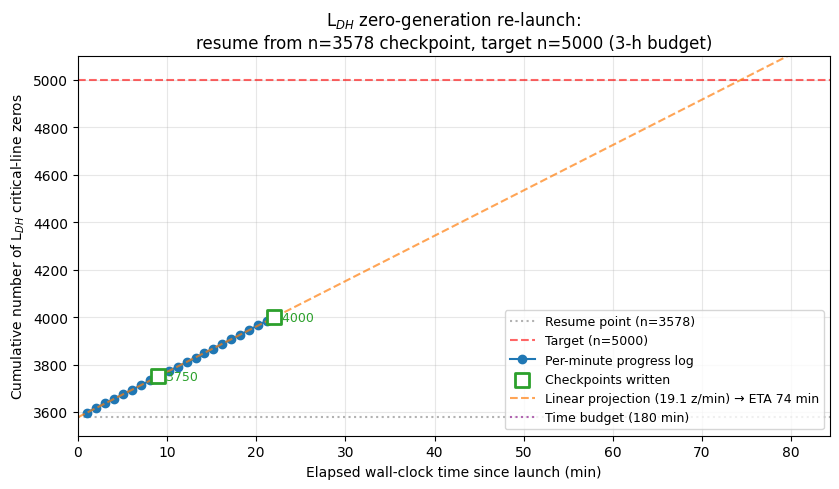

saved ldh_relaunch_progress.png


In [17]:
# Create the final summary figure
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8.5, 5))

# Resume point marker
ax.axhline(3578, color='gray', linestyle=':', alpha=0.6, label='Resume point (n=3578)')
ax.axhline(5000, color='red', linestyle='--', alpha=0.6, label='Target (n=5000)')

# Progress trace
ax.plot(elapsed_p, nzeros_p, 'o-', color='C0', label='Per-minute progress log')

# Checkpoints
ax.scatter(ckpt_elapsed, ckpt_nzeros, marker='s', s=110, facecolor='white',
 edgecolor='C2', linewidth=2, zorder=5, label='Checkpoints written')
for ce, cn in zip(ckpt_elapsed, ckpt_nzeros):
 ax.annotate(f' {cn}', (ce, cn), color='C2', fontsize=9, va='center')

# Linear projection
xfit = np.linspace(0, max(80, eta_min + 5), 200)
yfit = intercept + slope * xfit
ax.plot(xfit, yfit, '--', color='C1', alpha=0.7,
 label=f'Linear projection ({slope:.1f} z/min) → ETA {eta_min:.0f} min')

# Time-budget line
ax.axvline(180, color='purple', linestyle=':', alpha=0.6, label='Time budget (180 min)')

ax.set_xlabel('Elapsed wall-clock time since launch (min)')
ax.set_ylabel('Cumulative number of L$_{DH}$ critical-line zeros')
ax.set_title('L$_{DH}$ zero-generation re-launch:\nresume from n=3578 checkpoint, target n=5000 (3-h budget)')
ax.set_xlim(0, max(80, eta_min + 10))
ax.set_ylim(3500, 5100)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ldh_relaunch_progress.png', dpi=140)
plt.show()
print("saved ldh_relaunch_progress.png")


In [18]:
# Final verification before submitting: confirm process still alive and log up-to-date
import time
time.sleep(10)
print("Alive:", proc_alive(proc.pid))
with open(log_path) as f:
 print(f.read()[-1500:])
print("Checkpoints dir:", sorted(os.listdir(CKPT_DIR)))
print("PID file:", open(os.path.join(WORK_DIR, 'ldh_run.pid')).read())


Alive: True
2:44] PROGRESS: 3617 zeros, t=3574.67, elapsed=2.0min
[19:23:46] PROGRESS: 3637 zeros, t=3591.77, elapsed=3.1min
[19:24:48] PROGRESS: 3656 zeros, t=3609.77, elapsed=4.1min
[19:25:48] PROGRESS: 3675 zeros, t=3626.77, elapsed=5.1min
[19:26:48] PROGRESS: 3694 zeros, t=3644.47, elapsed=6.1min
[19:27:49] PROGRESS: 3713 zeros, t=3661.27, elapsed=7.1min
[19:28:50] PROGRESS: 3733 zeros, t=3678.37, elapsed=8.1min
[19:29:41] Checkpoint 03750: 3750 zeros, t=3691.77, elapsed=9.0min, rate=6.95 z/s, n_evals=3577
[19:29:50] PROGRESS: 3753 zeros, t=3694.07, elapsed=9.1min
[19:30:50] PROGRESS: 3773 zeros, t=3709.77, elapsed=10.2min
[19:31:50] PROGRESS: 3791 zeros, t=3727.77, elapsed=11.2min
[19:32:50] PROGRESS: 3810 zeros, t=3743.67, elapsed=12.2min
[19:33:50] PROGRESS: 3828 zeros, t=3761.37, elapsed=13.2min
[19:34:51] PROGRESS: 3848 zeros, t=3778.37, elapsed=14.2min
[19:35:53] PROGRESS: 3867 zeros, t=3796.17, elapsed=15.2min
[19:36:53] PROGRESS: 3887 zeros, t=3811.87, elapsed=16.2min
[19:3